# NWPU VHR-10 Object-Detection Baseline

This notebook:

1. creates deterministic train/validation/test splits;
2. converts NWPU annotations to YOLO format;
3. validates and visualizes the converted labels;
4. trains a pretrained YOLOv8n baseline;
5. evaluates on validation data.

The test split remains untouched until the final baseline is selected.

**Seed:** 42  
**Split:** 70% train, 15% validation, 15% test

**We need to run the boostrap code when we run code in Colab which clones the git repo in its local storage and also links to the shared resources that has dataset and other artifacts**

In [7]:
from pathlib import Path
import random

SEED = 42
random.seed(SEED)

# PROJECT_ROOT = Path.cwd()

# # Handle execution from the notebooks directory.
# if PROJECT_ROOT.name == "notebooks":
#     PROJECT_ROOT = PROJECT_ROOT.parent

# RAW_DATASET_ROOT = (
#     PROJECT_ROOT
#     / "shared_resources"
#     / "datasets"
#     / "raw"
# )

# PROCESSED_DATASET_ROOT = (
#     PROJECT_ROOT
#     / "shared_resources"
#     / "datasets"
#     / "processed"
#     / "nwpu_vhr10_yolo"
# )

# print("Project root:", PROJECT_ROOT)
# print("Raw dataset root:", RAW_DATASET_ROOT)
# print("Raw dataset exists:", RAW_DATASET_ROOT.exists())

### Colab Bootstrap below.

In [1]:
# ============================================================
# Colab bootstrap
# ============================================================

from google.colab import drive

from pathlib import Path
from shutil import copy2
from zipfile import ZipFile
import importlib
import os
import subprocess
import sys


# ============================================================
# Configuration: adjust these values
# ============================================================

REPOSITORY_URL = (
    "https://github.com/terriljoel/"
    "retrieval-grounded-remote-sensing.git"
)

BRANCH = "feat/object-detection-YOLO"

PROJECT_ROOT = Path(
    "/content/retrieval-grounded-remote-sensing"
)

DRIVE_SHARED_RESOURCES = Path(
    "/content/drive/"
    "Othercomputers/"
    "My laptop/"
    "shared_resources"
)

DATASET_ARCHIVE_NAME = (
    "NWPU VHR-10 dataset.zip"
)

LOCAL_CACHE_ROOT = Path(
    "/content/dataset_cache"
)

LOCAL_DATASETS_ROOT = Path(
    "/content/datasets"
)


# ============================================================
# Command helper
# ============================================================

def run_command(
    command: list[str],
    cwd: Path | None = None,
) -> None:
    """Run a command and stop immediately if it fails."""
    print("$", " ".join(command))

    subprocess.run(
        command,
        cwd=cwd,
        check=True,
        text=True,
    )


# ============================================================
# Google Drive
# ============================================================

def mount_google_drive() -> None:
    """Mount Google Drive in the Colab runtime."""
    print("Mounting Google Drive...")

    drive.mount(
        "/content/drive",
        force_remount=False,
    )


# ============================================================
# Git repository
# ============================================================

def prepare_repository() -> Path:
    """Clone the selected branch or pull its latest changes."""
    git_directory = PROJECT_ROOT / ".git"

    if git_directory.is_dir():
        print("Repository exists. Pulling updates...")

        run_command(
            [
                "git",
                "checkout",
                BRANCH,
            ],
            cwd=PROJECT_ROOT,
        )

        run_command(
            [
                "git",
                "pull",
                "--ff-only",
                "origin",
                BRANCH,
            ],
            cwd=PROJECT_ROOT,
        )

    elif PROJECT_ROOT.exists():
        raise RuntimeError(
            "The project path exists but is not a Git repository:\n"
            f"{PROJECT_ROOT}"
        )

    else:
        print("Cloning repository...")

        run_command([
            "git",
            "clone",
            "--branch",
            BRANCH,
            "--single-branch",
            REPOSITORY_URL,
            str(PROJECT_ROOT),
        ])

    return PROJECT_ROOT


# ============================================================
# Shared resources
# ============================================================

def connect_shared_resources() -> Path:
    """Link the cloned repository to shared resources in Drive."""
    if not DRIVE_SHARED_RESOURCES.is_dir():
        raise FileNotFoundError(
            "The shared_resources folder was not found:\n"
            f"{DRIVE_SHARED_RESOURCES}\n\n"
            "Check the spelling and capitalization of the "
            "Othercomputers and computer folder names."
        )

    project_shared_resources = (
        PROJECT_ROOT / "shared_resources"
    )

    if project_shared_resources.is_symlink():
        current_target = (
            project_shared_resources.resolve()
        )

        expected_target = (
            DRIVE_SHARED_RESOURCES.resolve()
        )

        if current_target != expected_target:
            raise RuntimeError(
                "The existing shared_resources link points to:\n"
                f"{current_target}\n\n"
                "Expected:\n"
                f"{expected_target}"
            )

        print(
            "Shared-resources link already configured:",
            current_target,
        )

    elif project_shared_resources.exists():
        raise RuntimeError(
            "A regular shared_resources directory already exists "
            "inside the cloned repository:\n"
            f"{project_shared_resources}\n\n"
            "The bootstrap will not replace it automatically."
        )

    else:
        os.symlink(
            DRIVE_SHARED_RESOURCES,
            project_shared_resources,
            target_is_directory=True,
        )

        print(
            "Created shared-resources link:\n"
            f"{project_shared_resources}\n"
            "->\n"
            f"{DRIVE_SHARED_RESOURCES}"
        )

    return project_shared_resources


# ============================================================
# Python installation
# ============================================================

def install_project() -> None:
    """Install dependencies and make the repository importable."""
    requirements_path = (
        PROJECT_ROOT / "requirements.txt"
    )

    if requirements_path.is_file():
        print("Installing project dependencies...")

        run_command([
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--requirement",
            str(requirements_path),
        ])

    else:
        print("No requirements.txt found.")

    packaging_exists = any([
        (PROJECT_ROOT / "pyproject.toml").is_file(),
        (PROJECT_ROOT / "setup.py").is_file(),
        (PROJECT_ROOT / "setup.cfg").is_file(),
    ])

    if packaging_exists:
        print("Installing the project in editable mode...")

        run_command([
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--editable",
            str(PROJECT_ROOT),
        ])

    else:
        project_path = str(PROJECT_ROOT)

        if project_path not in sys.path:
            sys.path.insert(
                0,
                project_path,
            )

        print(
            "No Python packaging configuration found. "
            "Added the project root to sys.path."
        )

    importlib.invalidate_caches()


# ============================================================
# Local dataset staging
# ============================================================

def stage_dataset_locally(
    shared_resources: Path,
) -> Path:
    """Copy and extract NWPU VHR-10 into fast temporary storage."""
    source_archive = (
        shared_resources
        / "datasets"
        / "archive"
        / DATASET_ARCHIVE_NAME
    )

    local_archive = (
        LOCAL_CACHE_ROOT
        / DATASET_ARCHIVE_NAME
    )

    local_raw_dataset = (
        LOCAL_DATASETS_ROOT / "raw"
    )

    extraction_marker = (
        local_raw_dataset
        / ".extraction_complete"
    )

    if not source_archive.is_file():
        raise FileNotFoundError(
            "Dataset archive was not found:\n"
            f"{source_archive}"
        )

    LOCAL_CACHE_ROOT.mkdir(
        parents=True,
        exist_ok=True,
    )

    if local_archive.is_file():
        print(
            "Dataset archive is already cached:",
            local_archive,
        )

    else:
        print("Copying dataset archive from Drive...")

        copy2(
            source_archive,
            local_archive,
        )

        print(
            "Dataset archive copied:",
            local_archive,
        )

    if extraction_marker.is_file():
        print(
            "Dataset is already extracted:",
            local_raw_dataset,
        )

    else:
        print("Extracting dataset...")

        local_raw_dataset.mkdir(
            parents=True,
            exist_ok=True,
        )

        with ZipFile(local_archive) as archive:
            archive.extractall(
                local_raw_dataset
            )

        extraction_marker.write_text(
            "Dataset extraction completed.\n",
            encoding="utf-8",
        )

        print(
            "Dataset extracted:",
            local_raw_dataset,
        )

    return local_raw_dataset


# ============================================================
# Output directories
# ============================================================

def prepare_output_paths(
    shared_resources: Path,
) -> dict[str, Path]:
    """Create local working and persistent output directories."""
    local_processed_datasets = (
        LOCAL_DATASETS_ROOT / "processed"
    )

    persistent_paths = {
        "manifests": (
            shared_resources
            / "datasets"
            / "manifests"
        ),
        "checkpoints": (
            shared_resources
            / "checkpoints"
        ),
        "experiment_outputs": (
            shared_resources
            / "experiment_outputs"
        ),
        "predictions": (
            shared_resources
            / "predictions"
        ),
    }

    local_processed_datasets.mkdir(
        parents=True,
        exist_ok=True,
    )

    for path in persistent_paths.values():
        path.mkdir(
            parents=True,
            exist_ok=True,
        )

    return {
        "processed_datasets": (
            local_processed_datasets
        ),
        **persistent_paths,
    }


# ============================================================
# Main bootstrap function
# ============================================================

def bootstrap_colab() -> dict[str, Path]:
    """Prepare the complete Colab project environment."""
    print("=" * 60)
    print("Starting Colab bootstrap")
    print("=" * 60)

    mount_google_drive()

    prepare_repository()

    shared_resources = (
        connect_shared_resources()
    )

    install_project()

    local_raw_dataset = (
        stage_dataset_locally(
            shared_resources
        )
    )

    output_paths = prepare_output_paths(
        shared_resources
    )

    os.chdir(PROJECT_ROOT)

    paths = {
        "project_root": PROJECT_ROOT,

        # Persistent Drive resources
        "shared_resources": shared_resources,

        # Fast temporary Colab storage
        "raw_datasets": local_raw_dataset,

        **output_paths,
    }

    print()
    print("=" * 60)
    print("Colab environment ready")
    print("=" * 60)

    for name, path in paths.items():
        print(
            f"{name:20s}: "
            f"{path} "
            f"[exists={path.exists()}]"
        )

    return paths


# ============================================================
# Run bootstrap
# ============================================================

PATHS = bootstrap_colab()

Mounted at /content/drive
Cloning repository...
$ git clone --branch feat/object-detection-YOLO --single-branch https://github.com/terriljoel/retrieval-grounded-remote-sensing.git /content/retrieval-grounded-remote-sensing
Created shared-resources link:
/content/retrieval-grounded-remote-sensing/shared_resources
->
/content/drive/Othercomputers/My laptop/shared_resources
Installing project dependencies...
$ /usr/bin/python3 -m pip install --quiet --requirement /content/retrieval-grounded-remote-sensing/requirements.txt
No Python packaging configuration found. Added the project root to sys.path.
Copying dataset archive from Drive...
Dataset archive copied: /content/dataset_cache/NWPU VHR-10 dataset.zip
Extracting dataset...
Dataset extracted: /content/datasets/raw

Colab environment ready
project_root        : /content/retrieval-grounded-remote-sensing [exists=True]
shared_resources    : /content/retrieval-grounded-remote-sensing/shared_resources [exists=True]
raw_datasets        : /con

In [14]:
PROJECT_ROOT = PATHS["project_root"]

RAW_DATASET_ROOT = PATHS[
    "raw_datasets"
]

PROCESSED_DATASET_ROOT = PATHS[
    "processed_datasets"
]

MANIFEST_ROOT = PATHS[
    "manifests"
]

CHECKPOINT_ROOT = PATHS[
    "checkpoints"
]

EXPERIMENT_OUTPUT_ROOT = PATHS[
    "experiment_outputs"
]

MANIFEST_PATH = (
    MANIFEST_ROOT
    / "nwpu_vhr10_multilabel_split_seed42.csv"
)

from src.data.adapters.nwpu import (
    discover_nwpu_items,
)

from src.data.splitting import (
    SplitConfig,
    create_dataset_splits,
    save_split_manifest,
)

print("Project imports successful.")

Project imports successful.


### Inspect the dataset

In [3]:
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.adapters.nwpu import discover_nwpu_items

items = discover_nwpu_items(RAW_DATASET_ROOT)

positive_items = [
    item for item in items
    if not item.is_background
]

background_items = [
    item for item in items
    if item.is_background
]

missing_annotations = [
    item.image_path
    for item in positive_items
    if item.annotation_path is None
]

print("Total images:", len(items))
print("Positive images:", len(positive_items))
print("Background images:", len(background_items))
print("Missing annotations:", len(missing_annotations))

Total images: 800
Positive images: 650
Background images: 150
Missing annotations: 0


In [6]:
from src.data.adapters.nwpu import (
    discover_nwpu_items,
)

from src.data.splitting import (
    SplitConfig,
    create_dataset_splits,
    save_split_manifest,
)

items = discover_nwpu_items(RAW_DATASET_ROOT)

print("Total images:", len(items))

Total images: 800


In [9]:


split_config = SplitConfig(
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    seed=SEED,
)

splits = create_dataset_splits(
    items=items,
    config=split_config,
    # stratify_backgrounds=True,
)

In [10]:
import pandas as pd

split_summary = []

for split_name, split_items in splits.items():
    background_count = sum(
        item.is_background
        for item in split_items
    )

    positive_count = (
        len(split_items) - background_count
    )

    split_summary.append({
        "split": split_name,
        "images": len(split_items),
        "positive": positive_count,
        "background": background_count,
        "background_%": (
            100
            * background_count
            / len(split_items)
        ),
    })

split_summary_df = pd.DataFrame(
    split_summary
)

display(
    split_summary_df.style.format({
        "background_%": "{:.2f}",
    })
)

,split,images,positive,background,background_%
0,train,562,457,105,18.68
1,val,120,98,22,18.33
2,test,118,95,23,19.49


In [13]:
from collections import Counter

from src.data.parsers.nwpu import (
    parse_nwpu_annotation,
)


CLASS_NAMES = {
    1: "airplane",
    2: "ship",
    3: "storage_tank",
    4: "baseball_diamond",
    5: "tennis_court",
    6: "basketball_court",
    7: "ground_track_field",
    8: "harbor",
    9: "bridge",
    10: "vehicle",
}


class_counts = {}

for split_name, split_items in splits.items():
    counter = Counter()

    for item in split_items:
        if item.is_background:
            continue

        boxes = parse_nwpu_annotation(
            item.annotation_path
        )

        # counter.update(
        #     box.class_id
        #     for box in boxes
        # )
        classes_in_image = {
            box.class_id
            for box in boxes
        }

        counter.update(classes_in_image)

    class_counts[split_name] = counter

records = []

for class_id, class_name in CLASS_NAMES.items():
    train_count = class_counts["train"][
        class_id
    ]

    val_count = class_counts["val"][
        class_id
    ]

    test_count = class_counts["test"][
        class_id
    ]

    total_count = (
        train_count
        + val_count
        + test_count
    )

    records.append({
        "class": class_name,
        "train": train_count,
        "val": val_count,
        "test": test_count,
        "total": total_count,
        "train_%": (
            100 * train_count / total_count
        ),
        "val_%": (
            100 * val_count / total_count
        ),
        "test_%": (
            100 * test_count / total_count
        ),
    })

class_distribution_df = pd.DataFrame(
    records
)

display(
    class_distribution_df.style.format({
        "train_%": "{:.1f}",
        "val_%": "{:.1f}",
        "test_%": "{:.1f}",
    })
)

,class,train,val,test,total,train_%,val_%,test_%
0,airplane,63,14,13,90,70.0,15.6,14.4
1,ship,40,8,9,57,70.2,14.0,15.8
2,storage_tank,20,4,4,28,71.4,14.3,14.3
3,baseball_diamond,123,26,27,176,69.9,14.8,15.3
4,tennis_court,76,16,16,108,70.4,14.8,14.8
5,basketball_court,60,13,13,86,69.8,15.1,15.1
6,ground_track_field,114,24,25,163,69.9,14.7,15.3
7,harbor,19,4,4,27,70.4,14.8,14.8
8,bridge,47,10,10,67,70.1,14.9,14.9
9,vehicle,60,13,13,86,69.8,15.1,15.1


### Save the split manifest in the storage output

In [15]:
from src.data.splitting import (
    save_split_manifest,
)


if MANIFEST_PATH.exists():
    raise FileExistsError(
        "A manifest already exists at:\n"
        f"{MANIFEST_PATH}\n"
        "Inspect it before deciding whether to replace it."
    )

saved_manifest = save_split_manifest(
    splits=splits,
    output_path=MANIFEST_PATH,
    dataset_root=RAW_DATASET_ROOT,
    config=split_config,
)

print("Split manifest saved:")
print(saved_manifest)

Split manifest saved:
/content/drive/Othercomputers/My laptop/shared_resources/datasets/manifests/nwpu_vhr10_multilabel_split_seed42.csv


In [16]:
import pandas as pd

saved_manifest_df = pd.read_csv(
    MANIFEST_PATH
)

display(
    saved_manifest_df.groupby(
        ["split", "is_background"]
    ).size()
)

print(
    "Manifest records:",
    len(saved_manifest_df),
)

assert len(saved_manifest_df) == len(items)
assert saved_manifest_df["image_path"].is_unique

print("Saved manifest verified.")

split  is_background
test   False             95
       True              23
train  False            457
       True             105
val    False             98
       True              22
dtype: int64

Manifest records: 800
Saved manifest verified.


## Convert NWPU annotations to YOLO format

NWPU format:

`(xmin, ymin), (xmax, ymax), class_id`

YOLO format:

`class_id x_center y_center width height`

NWPU class IDs `1–10` are mapped to YOLO IDs `0–9`.

In [51]:
from pathlib import Path
from shutil import rmtree


safe_processed_root = (
    PROCESSED_DATASET_ROOT.resolve()
)

target_directory = (
    YOLO_DATASET_ROOT.resolve()
)

if (
    target_directory == safe_processed_root
    or safe_processed_root
    not in target_directory.parents
):
    raise RuntimeError(
        "Refusing to remove a path outside the "
        "processed-dataset directory:\n"
        f"{target_directory}"
    )

if target_directory.exists():
    print(
        "Removing previous generated dataset:",
        target_directory,
    )

    rmtree(target_directory)

print("Output directory is ready.")

Removing previous generated dataset: /content/datasets/processed/nwpu_vhr10_yolo_seed42
Output directory is ready.


In [52]:
# ============================================================
# NWPU VHR-10 to YOLO conversion
# ============================================================

from __future__ import annotations

from collections import Counter
from pathlib import Path
from shutil import copy2
from typing import Any

from PIL import Image
import yaml

from src.data.models import BoundingBox, DatasetItem
from src.data.parsers.nwpu import (
    parse_nwpu_annotation,
)


# YOLO uses zero-based class IDs.
YOLO_CLASS_NAMES = {
    0: "airplane",
    1: "ship",
    2: "storage_tank",
    3: "baseball_diamond",
    4: "tennis_court",
    5: "basketball_court",
    6: "ground_track_field",
    7: "harbor",
    8: "bridge",
    9: "vehicle",
}


def create_unique_image_stem(
    item: DatasetItem,
) -> str:
    """Create an ID unique across positive and background folders."""
    source_prefix = (
        "background"
        if item.is_background
        else "positive"
    )

    return (
        f"{source_prefix}_"
        f"{item.image_path.stem}"
    )


def convert_box_to_yolo(
    box: BoundingBox,
    image_width: int,
    image_height: int,
) -> tuple[int, float, float, float, float]:
    """Convert one NWPU box into normalized YOLO format."""
    if image_width <= 0 or image_height <= 0:
        raise ValueError(
            "Image dimensions must be positive."
        )

    coordinates_are_valid = (
        0 <= box.xmin < box.xmax <= image_width
        and 0 <= box.ymin < box.ymax <= image_height
    )

    if not coordinates_are_valid:
        raise ValueError(
            f"Invalid box {box} for image size "
            f"{image_width}x{image_height}."
        )

    if box.class_id not in range(1, 11):
        raise ValueError(
            f"NWPU class ID must be between 1 and 10, "
            f"got {box.class_id}."
        )

    yolo_class_id = box.class_id - 1

    x_center = (
        (box.xmin + box.xmax)
        / 2
        / image_width
    )

    y_center = (
        (box.ymin + box.ymax)
        / 2
        / image_height
    )

    box_width = (
        box.xmax - box.xmin
    ) / image_width

    box_height = (
        box.ymax - box.ymin
    ) / image_height

    return (
        yolo_class_id,
        x_center,
        y_center,
        box_width,
        box_height,
    )


def format_yolo_box(
    box: BoundingBox,
    image_width: int,
    image_height: int,
) -> str:
    """Format one converted box as a YOLO label line."""
    (
        class_id,
        x_center,
        y_center,
        width,
        height,
    ) = convert_box_to_yolo(
        box=box,
        image_width=image_width,
        image_height=image_height,
    )

    return (
        f"{class_id} "
        f"{x_center:.8f} "
        f"{y_center:.8f} "
        f"{width:.8f} "
        f"{height:.8f}"
    )



In [53]:
def prepare_yolo_dataset_v2(
    splits,
    output_root: Path,
) -> Path:
    """Convert NWPU data with guaranteed-unique output names."""
    output_root = output_root.resolve()

    if output_root.exists() and any(
        output_root.iterdir()
    ):
        raise FileExistsError(
            f"Output directory is not empty: {output_root}"
        )

    for split_name in (
        "train",
        "val",
        "test",
    ):
        split_items = splits[split_name]

        image_directory = (
            output_root
            / "images"
            / split_name
        )

        label_directory = (
            output_root
            / "labels"
            / split_name
        )

        image_directory.mkdir(
            parents=True,
            exist_ok=True,
        )

        label_directory.mkdir(
            parents=True,
            exist_ok=True,
        )

        for item_index, item in enumerate(
            split_items
        ):
            source_type = (
                "background"
                if item.is_background
                else "positive"
            )

            # The split and sequential index guarantee uniqueness.
            unique_stem = (
                f"{split_name}_"
                f"{item_index:04d}_"
                f"{source_type}_"
                f"{item.image_path.stem}"
            )

            output_image = (
                image_directory
                / (
                    unique_stem
                    + item.image_path.suffix.lower()
                )
            )

            output_label = (
                label_directory
                / f"{unique_stem}.txt"
            )

            if output_image.exists():
                raise FileExistsError(
                    f"Duplicate image: {output_image}"
                )

            if output_label.exists():
                raise FileExistsError(
                    f"Duplicate label: {output_label}"
                )

            copy2(
                item.image_path,
                output_image,
            )

            if item.is_background:
                output_label.write_text(
                    "",
                    encoding="utf-8",
                )
                continue

            if item.annotation_path is None:
                raise ValueError(
                    "Positive image has no annotation: "
                    f"{item.image_path}"
                )

            with Image.open(
                item.image_path
            ) as image:
                image_width, image_height = (
                    image.size
                )

            boxes = parse_nwpu_annotation(
                item.annotation_path
            )

            label_lines = [
                format_yolo_box(
                    box=box,
                    image_width=image_width,
                    image_height=image_height,
                )
                for box in boxes
            ]

            output_label.write_text(
                "\n".join(label_lines) + "\n",
                encoding="utf-8",
            )

        written_images = sum(
            path.is_file()
            for path in image_directory.iterdir()
        )

        written_labels = len(list(
            label_directory.glob("*.txt")
        ))

        expected = len(split_items)

        print(
            f"{split_name}: expected={expected}, "
            f"images={written_images}, "
            f"labels={written_labels}"
        )

        if written_images != expected:
            raise RuntimeError(
                f"{split_name}: expected {expected} images, "
                f"wrote {written_images}"
            )

        if written_labels != expected:
            raise RuntimeError(
                f"{split_name}: expected {expected} labels, "
                f"wrote {written_labels}"
            )

    dataset_configuration = {
        "path": str(output_root),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": YOLO_CLASS_NAMES,
    }

    dataset_yaml = (
        output_root / "dataset.yaml"
    )

    with dataset_yaml.open(
        "w",
        encoding="utf-8",
    ) as file:
        yaml.safe_dump(
            dataset_configuration,
            file,
            sort_keys=False,
        )

    return dataset_yaml

In [54]:
YOLO_DATASET_ROOT = (
    PROCESSED_DATASET_ROOT
    / "nwpu_vhr10_yolo_seed42_v3"
)

DATASET_YAML = prepare_yolo_dataset_v2(
    splits=splits,
    output_root=YOLO_DATASET_ROOT,
)

print("Dataset YAML:", DATASET_YAML)

train: expected=562, images=562, labels=562
val: expected=120, images=120, labels=120
test: expected=118, images=118, labels=118
Dataset YAML: /content/datasets/processed/nwpu_vhr10_yolo_seed42_v3/dataset.yaml


## Validate converted YOLO labels

The conversion must preserve all 800 images and 3,896 objects. YOLO class IDs must be `0–9`, and normalized boxes must remain within image boundaries. Background images must have empty label files.

In [55]:
# ============================================================
# Validate generated YOLO dataset
# ============================================================

from collections import Counter
from pathlib import Path
import math

import pandas as pd


IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
}

validation_issues = []
validation_records = []
class_counts = Counter()

tolerance = 1e-6


for split_name in (
    "train",
    "val",
    "test",
):
    image_directory = (
        YOLO_DATASET_ROOT
        / "images"
        / split_name
    )

    label_directory = (
        YOLO_DATASET_ROOT
        / "labels"
        / split_name
    )

    if not image_directory.is_dir():
        validation_issues.append(
            f"Missing image directory: "
            f"{image_directory}"
        )
        continue

    if not label_directory.is_dir():
        validation_issues.append(
            f"Missing label directory: "
            f"{label_directory}"
        )
        continue

    image_paths = sorted(
        path
        for path in image_directory.iterdir()
        if (
            path.is_file()
            and path.suffix.lower()
            in IMAGE_EXTENSIONS
        )
    )

    label_paths = sorted(
        label_directory.glob("*.txt")
    )

    image_stems = {
        path.stem
        for path in image_paths
    }

    label_stems = {
        path.stem
        for path in label_paths
    }

    missing_label_stems = (
        image_stems - label_stems
    )

    orphan_label_stems = (
        label_stems - image_stems
    )

    for stem in sorted(missing_label_stems):
        validation_issues.append(
            f"{split_name}: missing label for "
            f"image {stem}"
        )

    for stem in sorted(orphan_label_stems):
        validation_issues.append(
            f"{split_name}: label has no image: "
            f"{stem}"
        )

    object_count = 0
    empty_label_count = 0

    for label_path in label_paths:
        lines = label_path.read_text(
            encoding="utf-8"
        ).splitlines()

        lines = [
            line.strip()
            for line in lines
            if line.strip()
        ]

        if not lines:
            empty_label_count += 1
            continue

        for line_number, line in enumerate(
            lines,
            start=1,
        ):
            location = (
                f"{label_path}:"
                f"{line_number}"
            )

            fields = line.split()

            if len(fields) != 5:
                validation_issues.append(
                    f"{location}: expected 5 fields, "
                    f"found {len(fields)}"
                )
                continue

            try:
                class_id = int(fields[0])

                (
                    x_center,
                    y_center,
                    width,
                    height,
                ) = map(float, fields[1:])

            except ValueError:
                validation_issues.append(
                    f"{location}: contains a "
                    "non-numeric value"
                )
                continue

            values = (
                x_center,
                y_center,
                width,
                height,
            )

            if not all(
                math.isfinite(value)
                for value in values
            ):
                validation_issues.append(
                    f"{location}: contains NaN "
                    "or infinity"
                )
                continue

            if class_id not in range(10):
                validation_issues.append(
                    f"{location}: invalid class ID "
                    f"{class_id}"
                )

            if not (
                0 <= x_center <= 1
                and 0 <= y_center <= 1
                and 0 < width <= 1
                and 0 < height <= 1
            ):
                validation_issues.append(
                    f"{location}: normalized values "
                    "are outside the YOLO range"
                )

            xmin = (
                x_center - width / 2
            )

            ymin = (
                y_center - height / 2
            )

            xmax = (
                x_center + width / 2
            )

            ymax = (
                y_center + height / 2
            )

            if not (
                xmin >= -tolerance
                and ymin >= -tolerance
                and xmax <= 1 + tolerance
                and ymax <= 1 + tolerance
            ):
                validation_issues.append(
                    f"{location}: box extends "
                    "outside the image"
                )

            object_count += 1
            class_counts[class_id] += 1

    validation_records.append({
        "split": split_name,
        "images": len(image_paths),
        "labels": len(label_paths),
        "objects": object_count,
        "empty_labels": empty_label_count,
    })


validation_df = pd.DataFrame(
    validation_records
).set_index("split")

display(validation_df)

,images,labels,objects,empty_labels
split,,,,
train,562,562,2842,105
val,120,120,531,22
test,118,118,523,23


In [56]:
total_images = int(
    validation_df["images"].sum()
)

total_labels = int(
    validation_df["labels"].sum()
)

total_objects = int(
    validation_df["objects"].sum()
)

total_empty_labels = int(
    validation_df["empty_labels"].sum()
)

print("Total images:", total_images)
print("Total labels:", total_labels)
print("Total objects:", total_objects)
print("Empty labels:", total_empty_labels)
print("Validation issues:", len(validation_issues))

Total images: 800
Total labels: 800
Total objects: 3896
Empty labels: 150
Validation issues: 0


## Visualize the YOLO dataset

In [58]:
# ============================================================
# Visual verification of YOLO labels
# ============================================================

import random

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw


VISUALIZATION_SEED = 42
random_generator = random.Random(
    VISUALIZATION_SEED
)


def find_matching_image(
    image_directory: Path,
    label_path: Path,
) -> Path:
    """Find an image with the same stem as a label file."""
    matches = [
        path
        for path in image_directory.iterdir()
        if (
            path.is_file()
            and path.stem == label_path.stem
            and path.suffix.lower()
            in IMAGE_EXTENSIONS
        )
    ]

    if len(matches) != 1:
        raise ValueError(
            f"Expected one image for {label_path}, "
            f"found {len(matches)}."
        )

    return matches[0]


def draw_yolo_labels(
    image_path: Path,
    label_path: Path,
) -> Image.Image:
    """Draw reconstructed YOLO boxes on an image."""
    image = Image.open(
        image_path
    ).convert("RGB")

    image_width, image_height = (
        image.size
    )

    drawing = ImageDraw.Draw(
        image
    )

    lines = [
        line.strip()
        for line in label_path.read_text(
            encoding="utf-8"
        ).splitlines()
        if line.strip()
    ]

    for line in lines:
        (
            class_id_text,
            x_center_text,
            y_center_text,
            width_text,
            height_text,
        ) = line.split()

        class_id = int(
            class_id_text
        )

        x_center = float(
            x_center_text
        )

        y_center = float(
            y_center_text
        )

        box_width = float(
            width_text
        )

        box_height = float(
            height_text
        )

        xmin = int(
            (
                x_center
                - box_width / 2
            )
            * image_width
        )

        ymin = int(
            (
                y_center
                - box_height / 2
            )
            * image_height
        )

        xmax = int(
            (
                x_center
                + box_width / 2
            )
            * image_width
        )

        ymax = int(
            (
                y_center
                + box_height / 2
            )
            * image_height
        )

        class_name = YOLO_CLASS_NAMES[
            class_id
        ]

        drawing.rectangle(
            (
                xmin,
                ymin,
                xmax,
                ymax,
            ),
            outline="red",
            width=3,
        )

        label_position = (
            xmin,
            max(0, ymin - 14),
        )

        drawing.text(
            label_position,
            class_name,
            fill="yellow",
            stroke_width=2,
            stroke_fill="black",
        )

    return image

def visualize_split(
    split_name: str,
    positive_samples: int = 3,
    background_samples: int = 1,
) -> None:
    image_directory = (
        YOLO_DATASET_ROOT
        / "images"
        / split_name
    )

    label_directory = (
        YOLO_DATASET_ROOT
        / "labels"
        / split_name
    )

    positive_labels = []
    background_labels = []

    for label_path in sorted(
        label_directory.glob("*.txt")
    ):
        content = label_path.read_text(
            encoding="utf-8"
        ).strip()

        if content:
            positive_labels.append(
                label_path
            )
        else:
            background_labels.append(
                label_path
            )

    selected_labels = (
        random_generator.sample(
            positive_labels,
            k=min(
                positive_samples,
                len(positive_labels),
            ),
        )
        + random_generator.sample(
            background_labels,
            k=min(
                background_samples,
                len(background_labels),
            ),
        )
    )

    figure, axes = plt.subplots(
        1,
        len(selected_labels),
        figsize=(
            6 * len(selected_labels),
            6,
        ),
    )

    if len(selected_labels) == 1:
        axes = [axes]

    for axis, label_path in zip(
        axes,
        selected_labels,
    ):
        image_path = find_matching_image(
            image_directory,
            label_path,
        )

        drawn_image = draw_yolo_labels(
            image_path,
            label_path,
        )

        is_background = not (
            label_path.read_text(
                encoding="utf-8"
            ).strip()
        )

        title_type = (
            "background"
            if is_background
            else "positive"
        )

        axis.imshow(
            drawn_image
        )

        axis.set_title(
            f"{split_name}: {title_type}\n"
            f"{image_path.name}"
        )

        axis.axis("off")

    plt.tight_layout()
    plt.show()

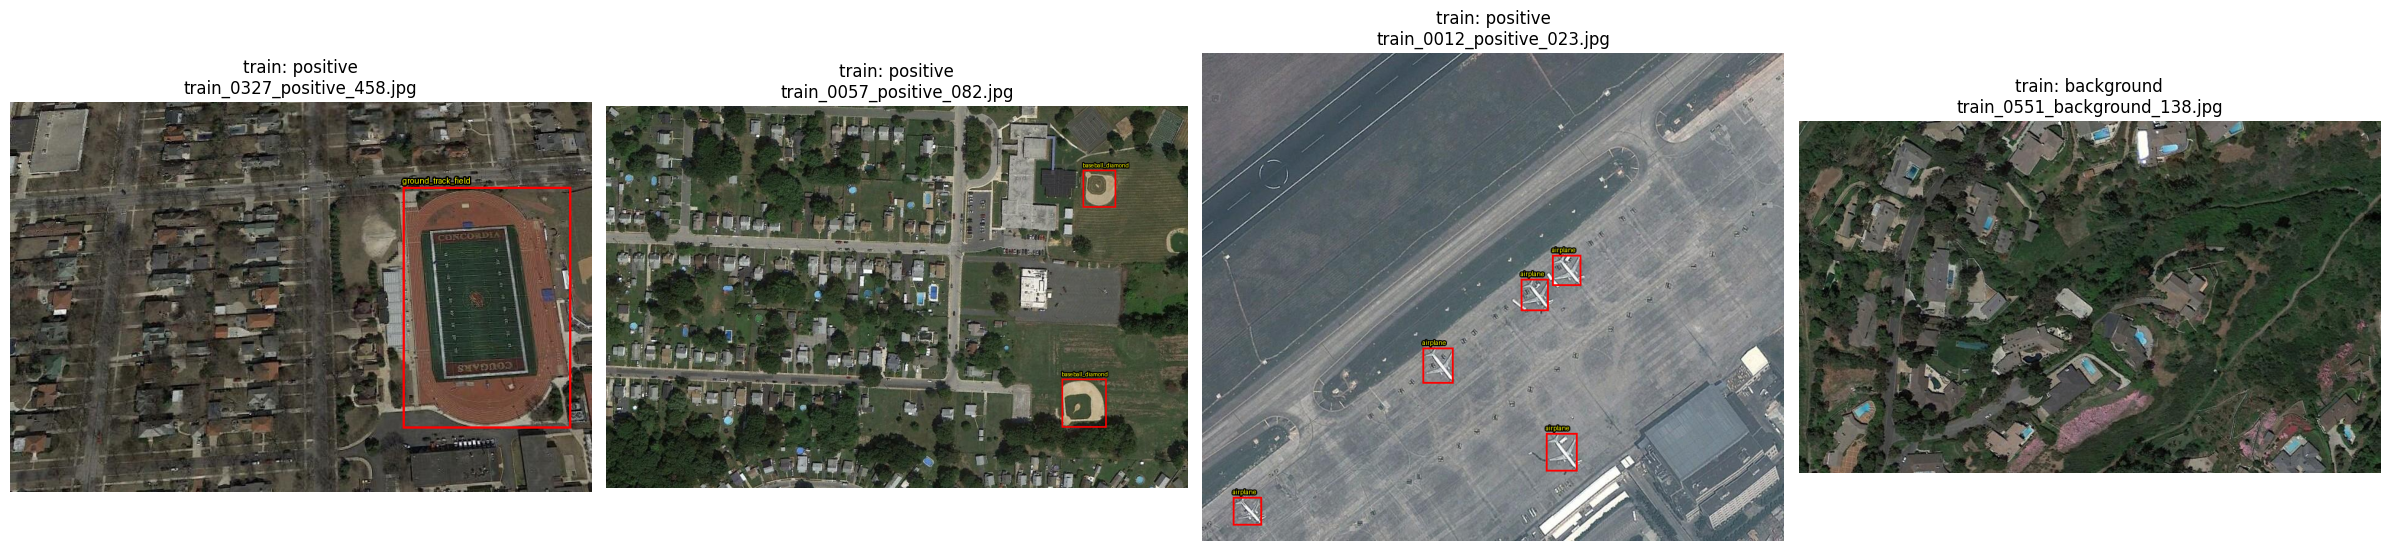

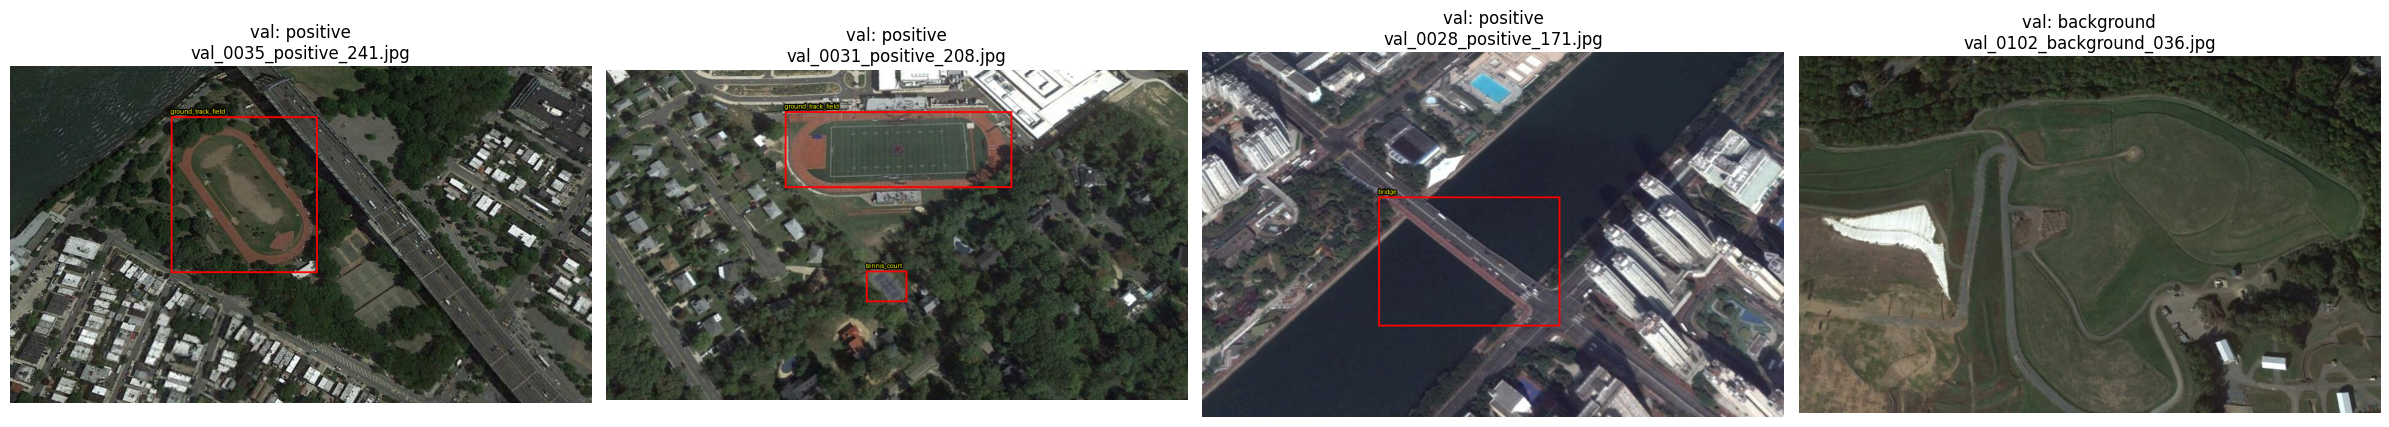

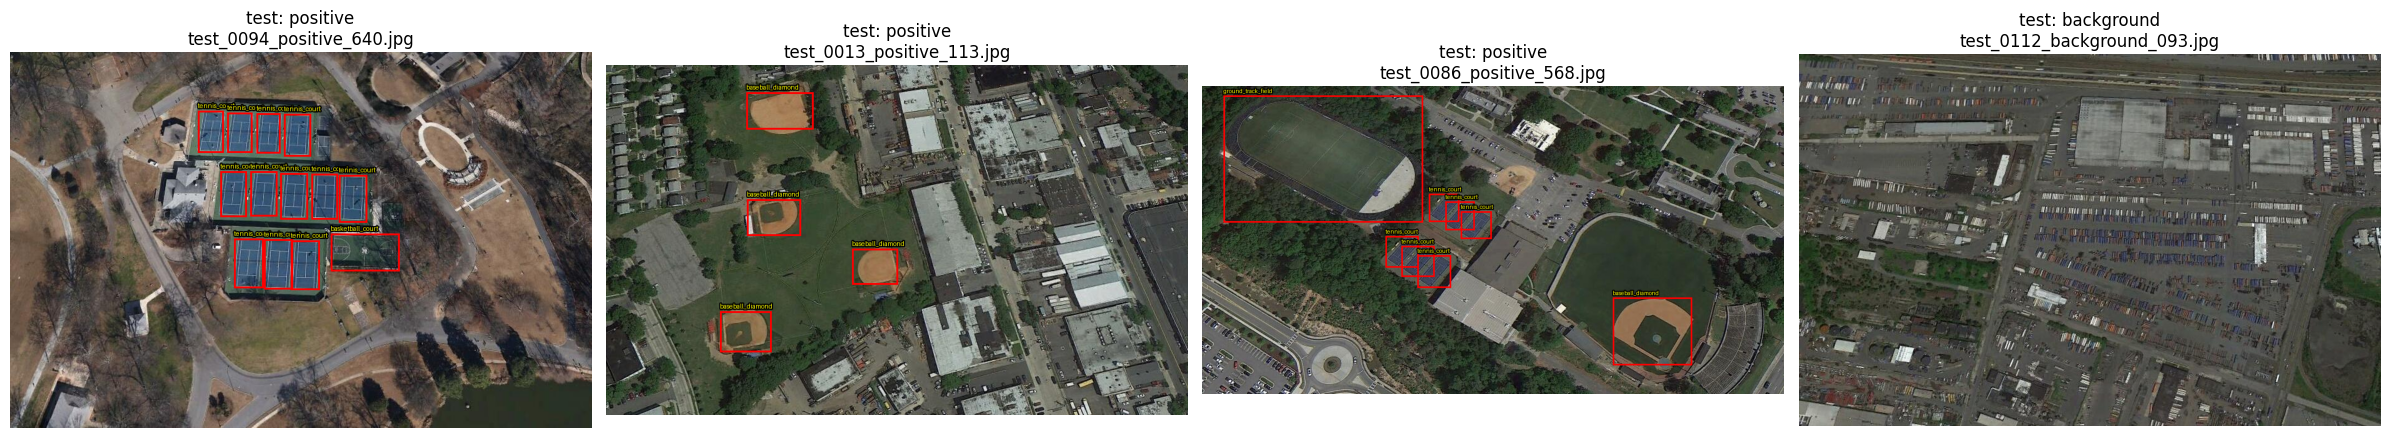

In [59]:
for split_name in (
    "train",
    "val",
    "test",
):
    visualize_split(
        split_name=split_name,
        positive_samples=3,
        background_samples=1,
    )

## Smoke Test on Training

In [60]:
%pip install --quiet ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.8 MB/s eta 0:00:00a 0:00:01


In [61]:
import torch
import ultralytics

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.112
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [62]:
from pathlib import Path

from ultralytics import YOLO


SMOKE_TEST_ROOT = Path(
    "/content/yolo_runs"
)

smoke_model = YOLO(
    "yolov8n.pt"
)

smoke_results = smoke_model.train(
    data=str(DATASET_YAML),
    epochs=1,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    seed=42,
    deterministic=True,
    pretrained=True,
    project=str(SMOKE_TEST_ROOT),
    name="yolov8n_smoke_test",
    exist_ok=False,
    plots=True,
    verbose=True,
)

Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/processed/nwpu_vhr10_yolo_seed42_v3/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, 

In [63]:
smoke_run_directory = Path(
    smoke_results.save_dir
)

smoke_best_checkpoint = (
    smoke_run_directory
    / "weights"
    / "best.pt"
)

smoke_last_checkpoint = (
    smoke_run_directory
    / "weights"
    / "last.pt"
)

print(
    "Run directory:",
    smoke_run_directory,
)

print(
    "Best checkpoint:",
    smoke_best_checkpoint,
    smoke_best_checkpoint.is_file(),
)

print(
    "Last checkpoint:",
    smoke_last_checkpoint,
    smoke_last_checkpoint.is_file(),
)

assert smoke_best_checkpoint.is_file()
assert smoke_last_checkpoint.is_file()

print("YOLO smoke test passed.")

Run directory: /content/yolo_runs/yolov8n_smoke_test
Best checkpoint: /content/yolo_runs/yolov8n_smoke_test/weights/best.pt True
Last checkpoint: /content/yolo_runs/yolov8n_smoke_test/weights/last.pt True
YOLO smoke test passed.


## Training 

In [64]:
from pathlib import Path

from ultralytics import YOLO


BASELINE_PROJECT_ROOT = (
    EXPERIMENT_OUTPUT_ROOT
    / "detection_baseline"
)

BASELINE_RUN_NAME = (
    "yolov8n_640_seed42"
)

baseline_model = YOLO(
    "yolov8n.pt"
)

In [65]:
baseline_results = baseline_model.train(
    data=str(DATASET_YAML),

    epochs=50,
    imgsz=640,
    batch=16,

    device=0,
    workers=2,

    seed=42,
    deterministic=True,

    optimizer="auto",
    warmup_epochs=3.0,
    cos_lr=False,
    lrf=0.01,

    patience=15,
    save=True,
    save_period=5,
    plots=True,

    project=str(
        BASELINE_PROJECT_ROOT
    ),
    name=BASELINE_RUN_NAME,
    exist_ok=False,
)

Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/processed/nwpu_vhr10_yolo_seed42_v3/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0,

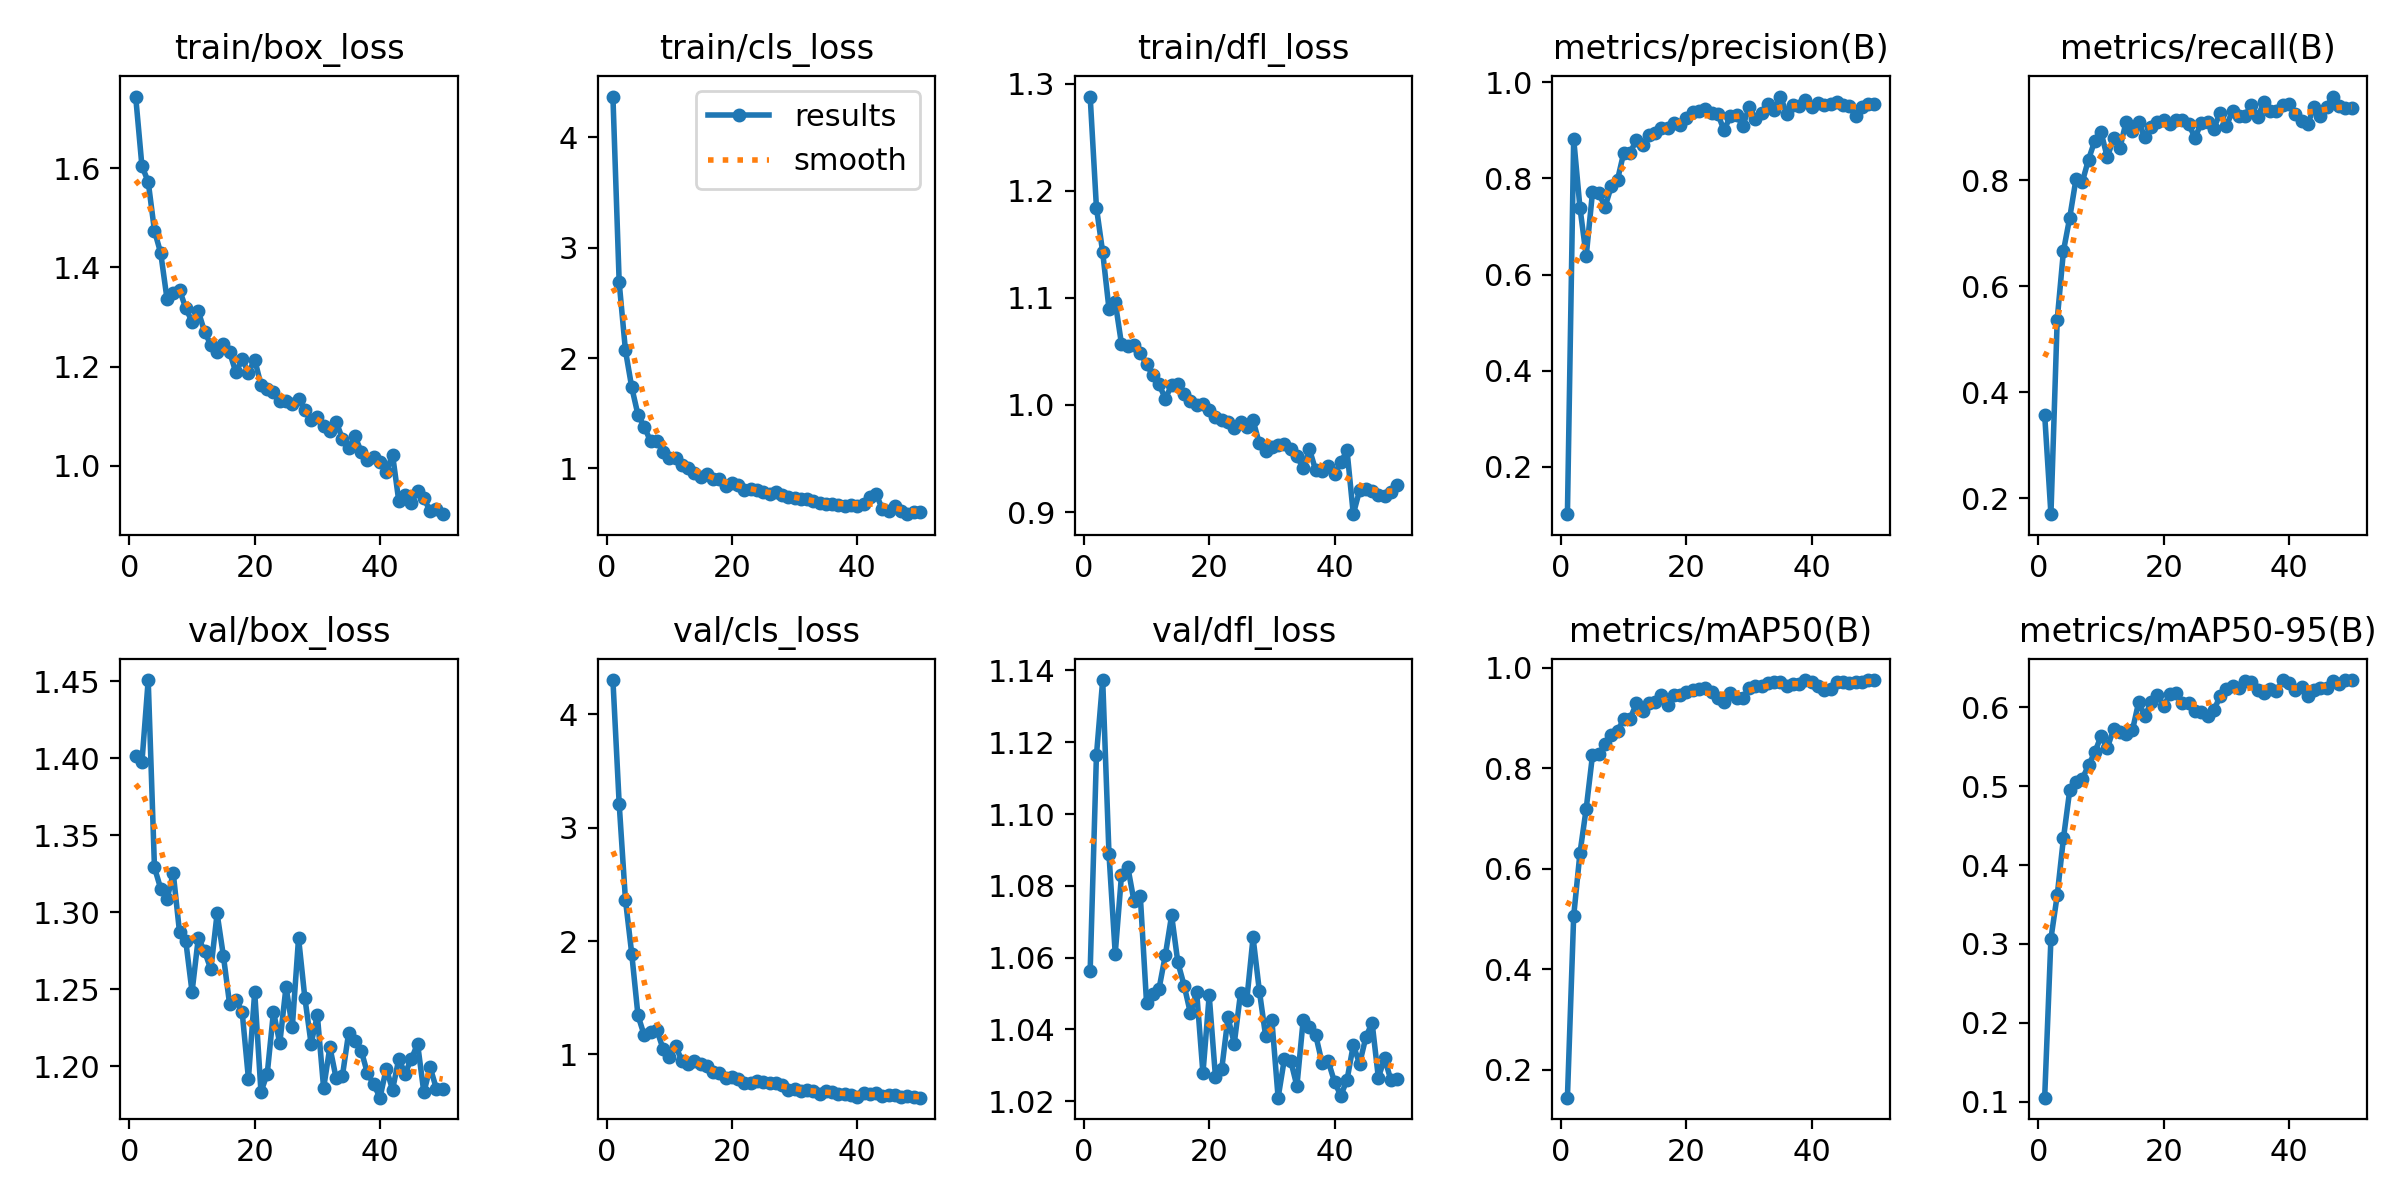

In [67]:
from IPython.display import Image as NotebookImage
from IPython.display import display

baseline_run_directory = Path(BASELINE_PROJECT_ROOT/ BASELINE_RUN_NAME)
results_image = (
    baseline_run_directory
    / "results.png"
)

assert results_image.is_file()

display(
    NotebookImage(
        filename=str(results_image)
    )
)

In [68]:
import pandas as pd
import matplotlib.pyplot as plt


results_csv = (
    baseline_run_directory
    / "results.csv"
)

training_history = pd.read_csv(
    results_csv
)

# Some Ultralytics versions include spaces in column names.
training_history.columns = [
    column.strip()
    for column in training_history.columns
]

print(training_history.columns.tolist())

display(training_history.tail())

['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
45,46,623.170,0.95007,0.65904,0.91954,0.95115,0.93769,0.96949,0.62405,1.21453,0.64063,1.04191,0.000078,0.000078,0.000078
46,47,636.762,0.93559,0.61437,0.91630,0.92909,0.95772,0.97274,0.63384,1.18294,0.62865,1.02656,0.000064,0.000064,0.000064
47,48,649.774,0.90845,0.58590,0.91529,0.94804,0.93940,0.97283,0.62952,1.19939,0.63104,1.03200,0.000050,0.000050,0.000050
48,49,661.579,0.91370,0.60272,0.91836,0.95398,0.93583,0.97578,0.63454,1.18535,0.62131,1.02583,0.000035,0.000035,0.000035
49,50,674.403,0.90283,0.60480,0.92532,0.95436,0.93533,0.97565,0.63405,1.18497,0.61910,1.02634,0.000021,0.000021,0.000021


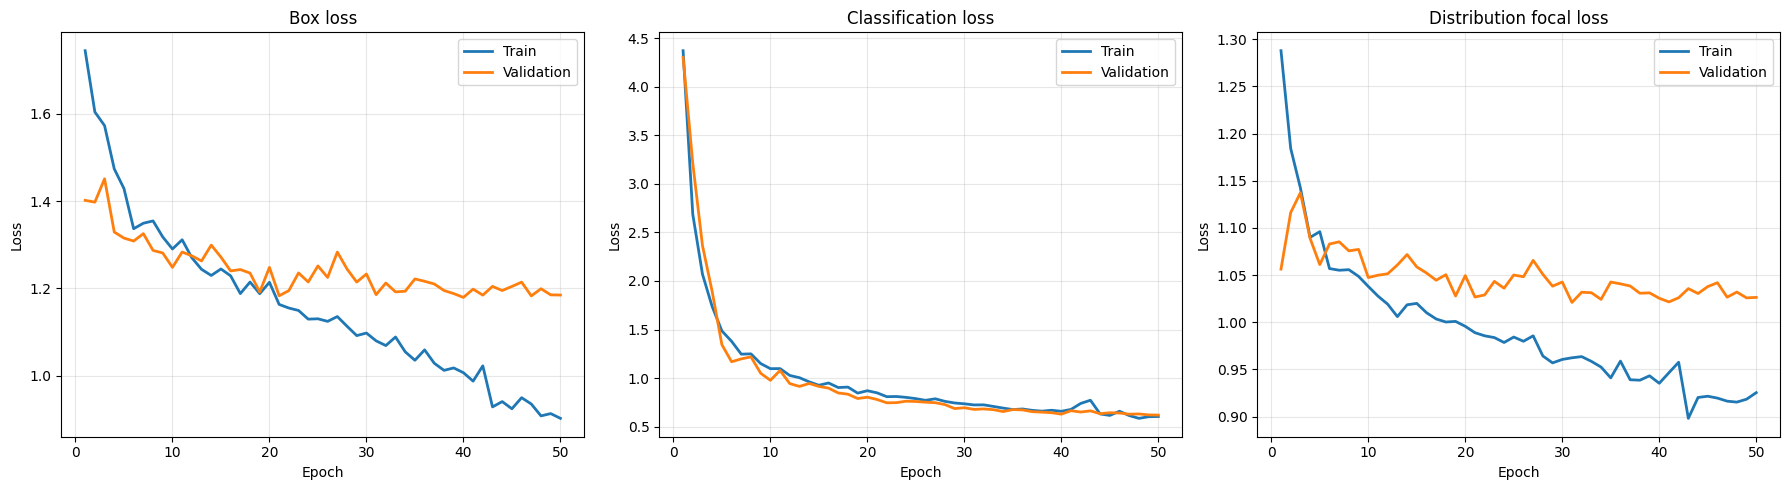

In [69]:
epoch = training_history["epoch"]


loss_pairs = [
    (
        "Box loss",
        "train/box_loss",
        "val/box_loss",
    ),
    (
        "Classification loss",
        "train/cls_loss",
        "val/cls_loss",
    ),
    (
        "Distribution focal loss",
        "train/dfl_loss",
        "val/dfl_loss",
    ),
]


figure, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)

for axis, (
    title,
    train_column,
    val_column,
) in zip(axes, loss_pairs):
    axis.plot(
        epoch,
        training_history[train_column],
        label="Train",
        linewidth=2,
    )

    axis.plot(
        epoch,
        training_history[val_column],
        label="Validation",
        linewidth=2,
    )

    axis.set_title(title)
    axis.set_xlabel("Epoch")
    axis.set_ylabel("Loss")
    axis.grid(alpha=0.3)
    axis.legend()

plt.tight_layout()
plt.show()

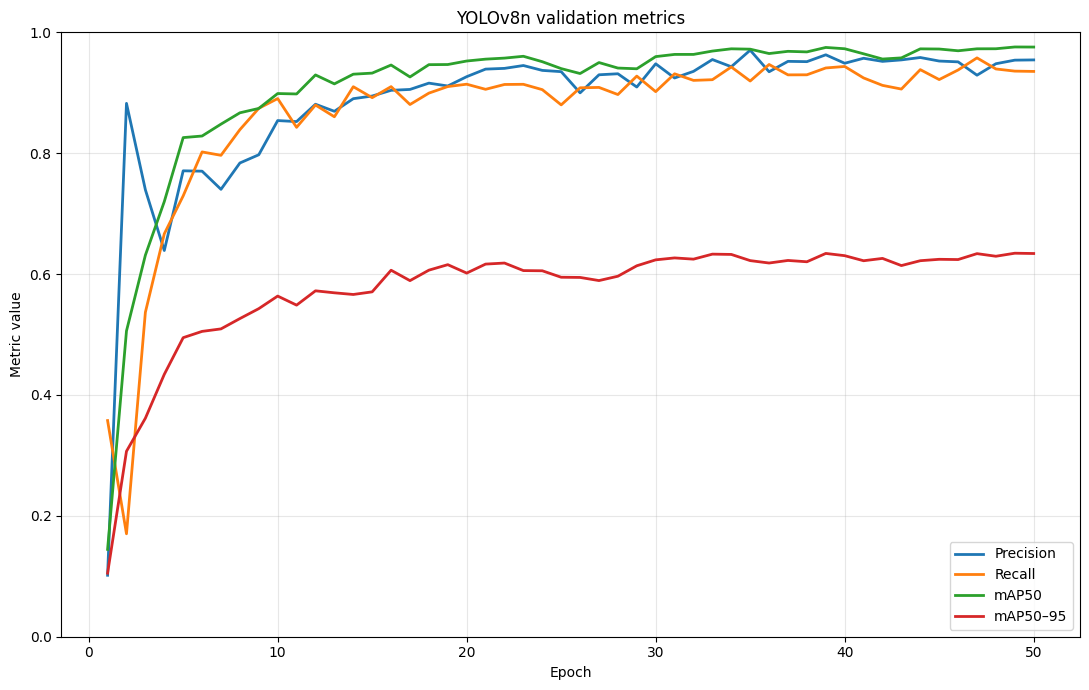

In [70]:
metric_columns = {
    "Precision": "metrics/precision(B)",
    "Recall": "metrics/recall(B)",
    "mAP50": "metrics/mAP50(B)",
    "mAP50–95": "metrics/mAP50-95(B)",
}


plt.figure(
    figsize=(11, 7)
)

for metric_name, column_name in (
    metric_columns.items()
):
    plt.plot(
        epoch,
        training_history[column_name],
        label=metric_name,
        linewidth=2,
    )

plt.title(
    "YOLOv8n validation metrics"
)
plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

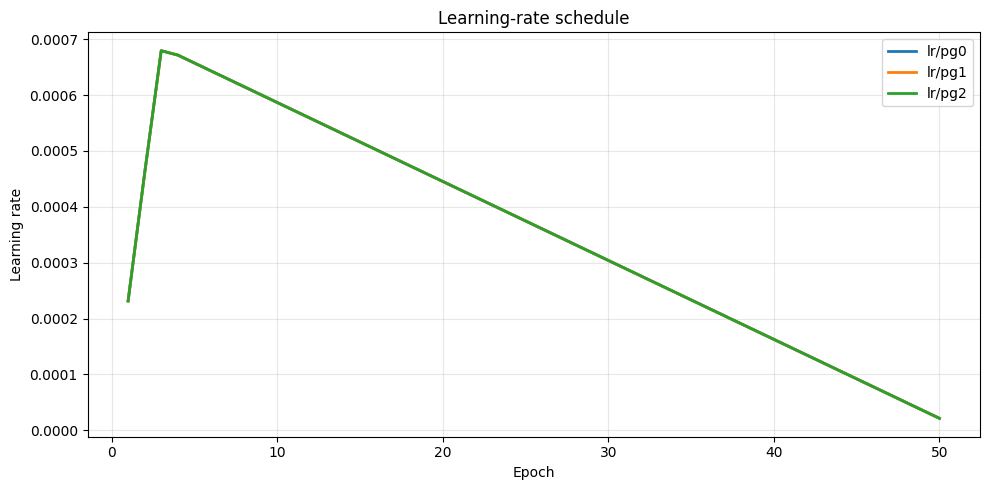

In [71]:
learning_rate_columns = [
    column
    for column in training_history.columns
    if column.startswith("lr/")
]

plt.figure(
    figsize=(10, 5)
)

for column in learning_rate_columns:
    plt.plot(
        epoch,
        training_history[column],
        label=column,
        linewidth=2,
    )

plt.title("Learning-rate schedule")
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
selection_metric = (
    "metrics/mAP50-95(B)"
)

best_row_index = (
    training_history[
        selection_metric
    ].idxmax()
)

best_epoch_metrics = (
    training_history.loc[
        best_row_index
    ]
)

print(
    "Best validation epoch:",
    int(best_epoch_metrics["epoch"]),
)

for metric_name, column_name in (
    metric_columns.items()
):
    print(
        f"{metric_name:10s}: "
        f"{best_epoch_metrics[column_name]:.4f}"
    )

Best validation epoch: 49
Precision : 0.9540
Recall    : 0.9358
mAP50     : 0.9758
mAP50–95  : 0.6345


## Test

In [75]:
best_checkpoint = Path(
    baseline_run_directory
    / "weights"
    / "best.pt"
)

In [76]:
from pathlib import Path

from ultralytics import YOLO


assert best_checkpoint.is_file()
assert DATASET_YAML.is_file()

TEST_PROJECT_ROOT = (
    EXPERIMENT_OUTPUT_ROOT
    / "detection_test"
)

TEST_RUN_NAME = (
    "yolov8n_640_seed42_test"
)

test_model = YOLO(
    str(best_checkpoint)
)

In [77]:
test_metrics = test_model.val(
    data=str(DATASET_YAML),
    split="test",

    imgsz=640,
    batch=16,

    device=0,
    workers=2,

    plots=True,
    verbose=True,

    project=str(TEST_PROJECT_ROOT),
    name=TEST_RUN_NAME,
    exist_ok=False,
)

Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1734.3±687.3 MB/s, size: 87.6 KB)
val: Scanning /content/datasets/processed/nwpu_vhr10_yolo_seed42_v3/labels/test... 118 images, 23 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 118/118 2.1Kit/s 0.1s
val: New cache created: /content/datasets/processed/nwpu_vhr10_yolo_seed42_v3/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.5it/s 3.2s0.3ss
                   all        118        523      0.927      0.932      0.962      0.637
              airplane         13        101      0.965       0.99      0.984      0.684
                  ship          9         48      0.974       0.79      0.869      0.572
          storage_tank          4         70      0.851      0.986      0.981      0.592
      ba

In [78]:
overall_test_metrics = {
    "precision": float(
        test_metrics.box.mp
    ),
    "recall": float(
        test_metrics.box.mr
    ),
    "mAP50": float(
        test_metrics.box.map50
    ),
    "mAP50_95": float(
        test_metrics.box.map
    ),
}

for metric_name, value in (
    overall_test_metrics.items()
):
    print(
        f"{metric_name:12s}: "
        f"{value:.4f}"
    )

precision   : 0.9271
recall      : 0.9317
mAP50       : 0.9619
mAP50_95    : 0.6372


In [79]:
import pandas as pd


per_class_records = []

for result_index, class_id in enumerate(
    test_metrics.box.ap_class_index
):
    class_id = int(class_id)

    (
        precision,
        recall,
        ap50,
        ap50_95,
    ) = test_metrics.class_result(
        result_index
    )

    per_class_records.append({
        "class_id": class_id,
        "class_name": test_metrics.names[
            class_id
        ],
        "precision": float(precision),
        "recall": float(recall),
        "AP50": float(ap50),
        "AP50_95": float(ap50_95),
    })


per_class_test_metrics = pd.DataFrame(
    per_class_records
).sort_values("class_id")

display(
    per_class_test_metrics.style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "AP50": "{:.4f}",
        "AP50_95": "{:.4f}",
    })
)

,class_id,class_name,precision,recall,AP50,AP50_95
0,0,airplane,0.9649,0.9901,0.9835,0.6836
1,1,ship,0.9743,0.7901,0.8692,0.5721
2,2,storage_tank,0.8508,0.9857,0.9809,0.5916
3,3,baseball_diamond,0.9788,0.9643,0.9905,0.7151
4,4,tennis_court,0.9357,0.9857,0.9942,0.7346
5,5,basketball_court,1.0000,0.8797,0.9576,0.6525
6,6,ground_track_field,0.9245,1.0000,0.9950,0.8495
7,7,harbor,0.8666,0.9993,0.9713,0.5002
8,8,bridge,0.8337,0.9404,0.9634,0.4649
9,9,vehicle,0.9413,0.7819,0.9134,0.6082


In [80]:
import json


test_run_directory = Path(
    getattr(
        test_metrics,
        "save_dir",
        TEST_PROJECT_ROOT / TEST_RUN_NAME,
    )
)

test_run_directory.mkdir(
    parents=True,
    exist_ok=True,
)

overall_metrics_path = (
    test_run_directory
    / "overall_test_metrics.json"
)

per_class_metrics_path = (
    test_run_directory
    / "per_class_test_metrics.csv"
)

overall_metrics_path.write_text(
    json.dumps(
        overall_test_metrics,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)

per_class_test_metrics.to_csv(
    per_class_metrics_path,
    index=False,
)

print("Test outputs:", test_run_directory)
print("Overall metrics:", overall_metrics_path)
print("Per-class metrics:", per_class_metrics_path)

Test outputs: /content/drive/Othercomputers/My laptop/shared_resources/experiment_outputs/detection_test/yolov8n_640_seed42_test
Overall metrics: /content/drive/Othercomputers/My laptop/shared_resources/experiment_outputs/detection_test/yolov8n_640_seed42_test/overall_test_metrics.json
Per-class metrics: /content/drive/Othercomputers/My laptop/shared_resources/experiment_outputs/detection_test/yolov8n_640_seed42_test/per_class_test_metrics.csv
